# Task 1: Dataset Understanding

In [288]:
import pandas as pd
import os
import random
import numpy as np
import tensorflow as tf

os.environ['PYTHONHASHSEED'] = '42'
os.environ['TF_DETERMINISTIC_OPS'] = '1'

random.seed(42)
np.random.seed(42)

tf.keras.utils.set_random_seed(42)

tf.config.experimental.enable_op_determinism()

#### Number of rows and columns


In [289]:

df = pd.read_csv("customer_churn_nn.csv")
rows, columns = df.shape
print("Number of rows:", rows)
print("Number of columns:", columns)


Number of rows: 2000
Number of columns: 17


Explanation :
The dataset contains 2000 rows and 17 columns.
Rows represent customer records and columns represent features.

#### b. Type of input features

In [290]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   customer_id                   2000 non-null   str    
 1   region                        2000 non-null   str    
 2   plan_type                     2000 non-null   str    
 3   contract_type                 2000 non-null   str    
 4   payment_method                2000 non-null   str    
 5   tenure_months                 2000 non-null   int64  
 6   monthly_charges_inr           2000 non-null   float64
 7   avg_login_days_per_month      2000 non-null   int64  
 8   support_tickets_last_90_days  2000 non-null   int64  
 9   payment_delay_days            2000 non-null   int64  
 10  data_usage_gb                 2000 non-null   float64
 11  satisfaction_score            2000 non-null   float64
 12  last_complaint_days_ago       2000 non-null   int64  
 13  discount_perce

Explanation :
The dataset contains both numerical and categorical features.
Categorical columns include region, plan_type, contract_type, and payment_method.
Remaining columns are numerical features.

#### c. Target variable description


In [291]:
print(df['churn'].unique())

[0 1]


Explanation :
The target variable is 'churn'.
It is a binary classification problem where:
0 represents retained customers and
1 represents churned customers.

#### d. Missing value check

In [292]:
print(df.isnull().sum())

customer_id                     0
region                          0
plan_type                       0
contract_type                   0
payment_method                  0
tenure_months                   0
monthly_charges_inr             0
avg_login_days_per_month        0
support_tickets_last_90_days    0
payment_delay_days              0
data_usage_gb                   0
satisfaction_score              0
last_complaint_days_ago         0
discount_percent                0
autopay_enabled                 0
referral_count                  0
churn                           0
dtype: int64


Explanation :
The dataset does not contain any missing values.
All columns have 2000 non-null entries.
Therefore, missing value handling is not required.

#### e. Basic statistical summary


In [293]:
df.describe()

,tenure_months,monthly_charges_inr,avg_login_days_per_month,support_tickets_last_90_days,payment_delay_days,data_usage_gb,satisfaction_score,last_complaint_days_ago,discount_percent,autopay_enabled,referral_count,churn
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,25.362000,766.487295,18.099000,1.953000,3.555000,90.007625,6.87395,46.616500,8.255000,0.597500,0.918000,0.015500
std,14.128651,393.420070,5.400628,1.463852,3.885682,53.215719,1.52428,55.065775,7.553708,0.490524,1.041546,0.123561
min,1.000000,255.450000,0.000000,0.000000,0.000000,0.500000,1.00000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,15.000000,427.782500,15.000000,1.000000,1.000000,51.777500,5.87500,6.000000,0.000000,0.000000,0.000000,0.000000
50%,23.000000,688.355000,18.000000,2.000000,2.000000,80.245000,6.80000,28.500000,5.000000,1.000000,1.000000,0.000000
75%,33.000000,1007.372500,22.000000,3.000000,5.000000,119.097500,8.00000,68.000000,15.000000,1.000000,1.000000,0.000000
max,72.000000,2156.520000,30.000000,8.000000,31.000000,265.510000,10.00000,424.000000,20.000000,1.000000,7.000000,1.000000


Explanation :
The statistical summary shows the distribution of numerical features.
The dataset contains varying ranges of values across columns such as tenure, monthly charges, and satisfaction score.
This indicates that feature scaling may be required during preprocessing.

#### f. Distribution of the target variable


C:\Users\Home\AppData\Local\Temp\ipykernel_9396\4291434082.py:52: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1,0].set_xticklabels([


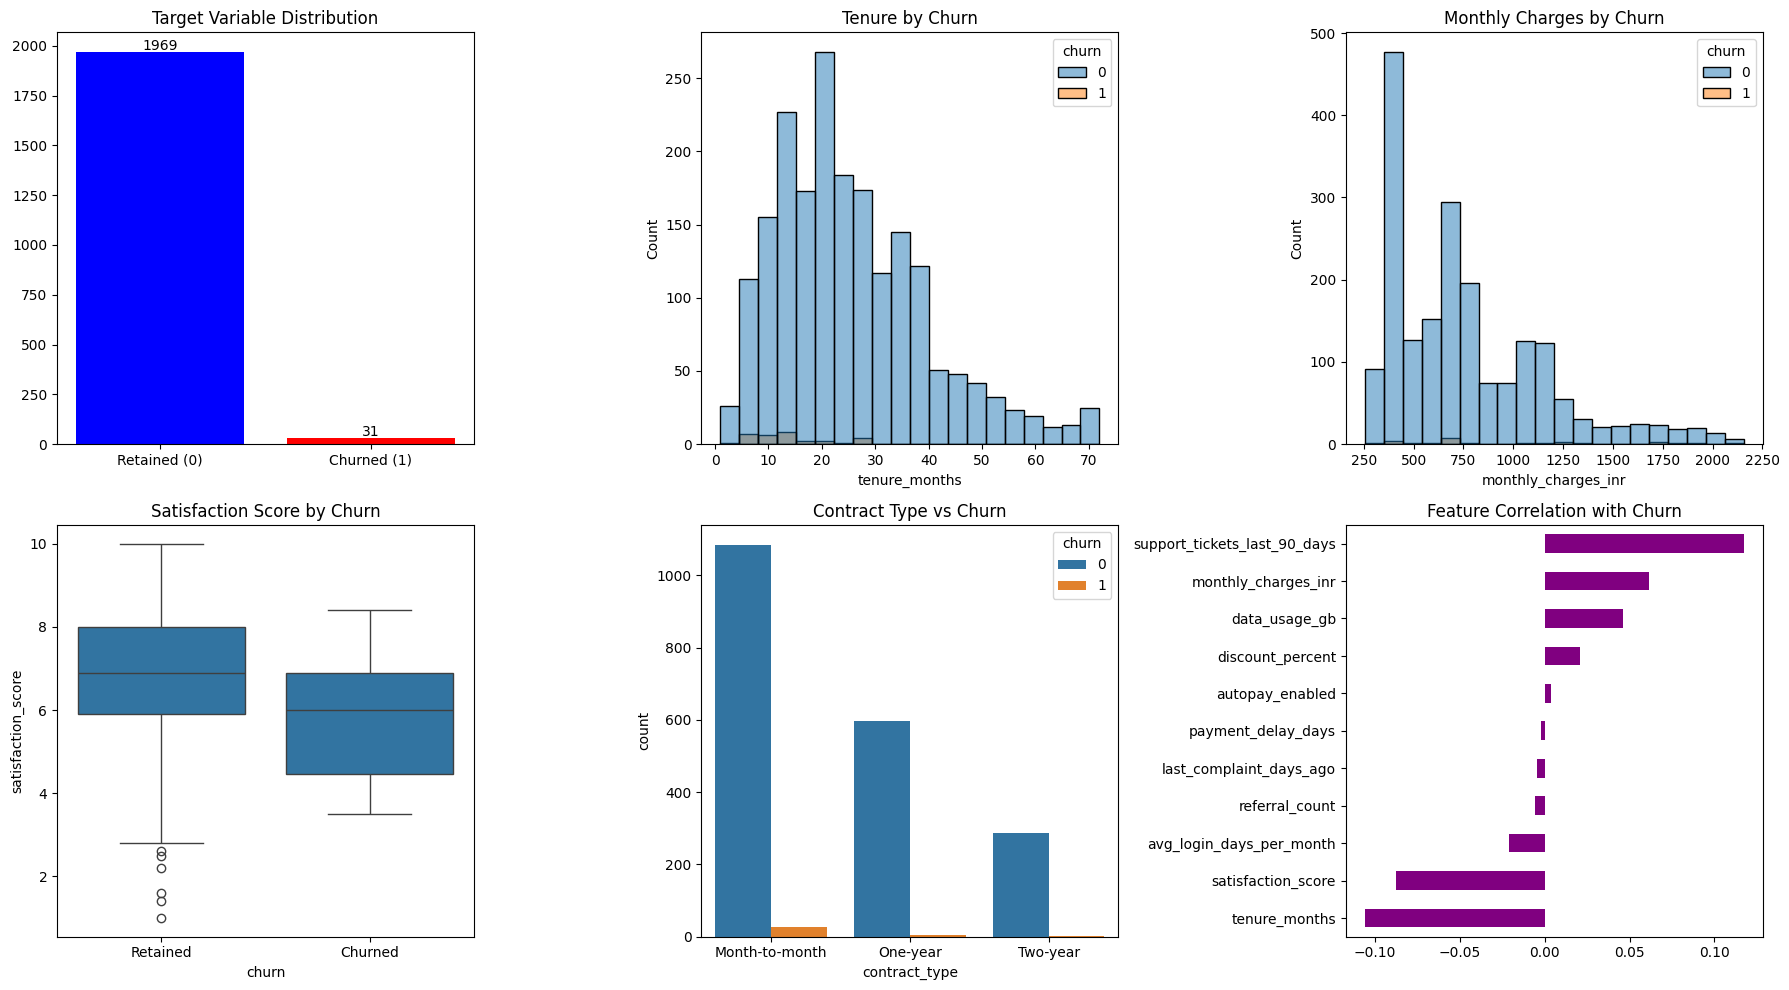

In [294]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Target Variable Distribution
target_counts = df['churn'].value_counts()

axes[0,0].bar(
    ['Retained (0)', 'Churned (1)'],
    target_counts.values,
    color=['blue', 'red']
)

axes[0,0].set_title('Target Variable Distribution')

for i, v in enumerate(target_counts.values):
    axes[0,0].text(i, v + 10, str(v), ha='center')

# Tenure by Churn
sns.histplot(
    data=df,
    x='tenure_months',
    hue='churn',
    bins=20,
    ax=axes[0,1]
)

axes[0,1].set_title('Tenure by Churn')

# Monthly Charges by Churn
sns.histplot(
    data=df,
    x='monthly_charges_inr',
    hue='churn',
    bins=20,
    ax=axes[0,2]
)

axes[0,2].set_title('Monthly Charges by Churn')

# Satisfaction Score by Churn
sns.boxplot(
    data=df,
    x='churn',
    y='satisfaction_score',
    ax=axes[1,0]
)

axes[1,0].set_title('Satisfaction Score by Churn')

axes[1,0].set_xticklabels([
    'Retained',
    'Churned'
])

# Contract Type vs Churn
sns.countplot(
    data=df,
    x='contract_type',
    hue='churn',
    ax=axes[1,1]
)

axes[1,1].set_title('Contract Type vs Churn')

# Feature Correlation with Churn
correlation = df.corr(
    numeric_only=True
)['churn'].sort_values()

correlation.drop('churn').plot(
    kind='barh',
    ax=axes[1,2],
    color='purple'
)

axes[1,2].set_title('Feature Correlation with Churn')

plt.tight_layout()



plt.show()

Explanation :
The target variable distribution shows severe class imbalance.
The dataset contains 1969 retained customers and only 31 churned customers.
This imbalance may affect model performance during training.

# Task 2: Data Preprocessing


#### a. Handling missing values, if any


In [295]:
print(df.isnull().sum())

customer_id                     0
region                          0
plan_type                       0
contract_type                   0
payment_method                  0
tenure_months                   0
monthly_charges_inr             0
avg_login_days_per_month        0
support_tickets_last_90_days    0
payment_delay_days              0
data_usage_gb                   0
satisfaction_score              0
last_complaint_days_ago         0
discount_percent                0
autopay_enabled                 0
referral_count                  0
churn                           0
dtype: int64


Explanation :
The dataset does not contain any missing values.
Therefore, no missing value handling was required during preprocessing.

#### b. Encoding categorical columns, if present

In [296]:
df = df.drop('customer_id', axis=1)


df = pd.get_dummies(
    df,
    columns=['region', 'plan_type', 'contract_type', 'payment_method'],
    drop_first=True
)

encoded_columns = [
    col for col in df.columns
    if 'region_' in col
    or 'plan_type_' in col
    or 'contract_type_' in col
    or 'payment_method_' in col
]


print(df[encoded_columns].head())

   region_East  region_North  region_South  region_West  plan_type_Enterprise  \
0        False         False          True        False                 False   
1        False         False         False         True                 False   
2        False         False         False        False                 False   
3        False         False         False         True                 False   
4        False          True         False        False                 False   

   plan_type_Premium  plan_type_Standard  contract_type_One-year  \
0              False                True                   False   
1               True               False                   False   
2              False                True                   False   
3               True               False                   False   
4               True               False                   False   

   contract_type_Two-year  payment_method_Debit Card  \
0                   False                       

Explanation :
Categorical columns such as region, plan_type, contract_type, and payment_method were converted into numerical format using one-hot encoding.
The customer_id column was removed because it is only an identifier and not useful for prediction. After encoding, the dataset became suitable for neural network training.

#### c. Scaling or normalizing numerical features

In [297]:
from sklearn.preprocessing import StandardScaler

In [298]:
from sklearn.preprocessing import StandardScaler

numerical_columns = [
    'tenure_months',
    'monthly_charges_inr',
    'avg_login_days_per_month',
    'support_tickets_last_90_days',
    'payment_delay_days',
    'data_usage_gb',
    'satisfaction_score',
    'last_complaint_days_ago',
    'discount_percent',
    'autopay_enabled',
    'referral_count'
]

scaler = StandardScaler()

df[numerical_columns] = scaler.fit_transform(df[numerical_columns])

print(df[numerical_columns].head())

   tenure_months  monthly_charges_inr  avg_login_days_per_month  \
0       0.328351            -0.201075                 -0.944386   
1      -0.733587             0.669306                  0.722504   
2       3.301778            -0.087504                 -0.944386   
3      -0.238016             0.490750                  0.166874   
4      -1.016770             0.314533                 -0.018336   

   support_tickets_last_90_days  payment_delay_days  data_usage_gb  \
0                     -1.334485           -0.915126      -0.038299   
1                      0.715415           -0.657707      -0.147317   
2                     -1.334485            1.916488      -0.011609   
3                      0.032115           -0.142868       0.934589   
4                      0.032115            0.629391       1.248484   

   satisfaction_score  last_complaint_days_ago  discount_percent  \
0            0.738927                 0.370259         -1.093114   
1           -0.770360                 0.

Explanation :
Numerical features were scaled using StandardScaler to bring all values into a similar range. Feature scaling helps improve neural network training efficiency and stability.

#### d. Splitting the dataset into training and testing sets

In [299]:
from sklearn.model_selection import train_test_split

x = df.drop('churn', axis=1)
y = df['churn']

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("x_train shape:", x_train.shape)
print("x_test shape:", x_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

x_train shape: (1600, 24)
x_test shape: (400, 24)
y_train shape: (1600,)
y_test shape: (400,)


Explanation :
The dataset was divided into training and testing sets using an 80:20 ratio. Training data was used for model learning, while testing data was reserved for performance evaluation on unseen samples.

# Task 3: Neural Network Model Building

In [300]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential()
model.add(Dense(16, activation='relu', input_shape=(24,)))
model.add(Dense(1, activation='sigmoid'))
model.compile(
    loss='binary_crossentropy'
)
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

c:\Users\Home\Desktop\Business Analytics with Gen AI\Neural Networks & Deep Learning\Assignment Module 5\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


#### a. Input layer
The Sequential model is used because the neural network follows a simple feed-forward architecture where layers are connected in a linear sequence.
After preprocessing and encoding, the dataset contains 24 input features. Therefore, the neural network input layer consists of 24 input neurons.

#### b. At least one hidden layer
A hidden layer with 16 neurons was added to the neural network. The hidden layer helps the model learn patterns and relationships from the input data.

#### c. Activation function in the hidden layer
The ReLU activation function was used in the hidden layer. ReLU helps the neural network learn complex non-linear patterns efficiently and improves training performance.

#### d. Output layer suitable for the target variable
The output layer contains one neuron with sigmoid activation because the problem is a binary classification task. The sigmoid function produces output values between 0 and 1, representing churn probability.

#### e. Appropriate loss function
Binary crossentropy is used as the loss function because the problem is a binary classification task. The loss function measures the difference between actual and predicted outputs during training.

#### f. Appropriate optimizer
The Adam optimizer is used to update model weights during training. Adam is widely used because it provides efficient and stable learning performance.
Accuracy is used as the evaluation metric.

# Task 4: Training and Evaluation


#### a. Training accuracy/loss

In [301]:
history = model.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    class_weight={0:1, 1:15}

)

Epoch 1/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.5734 - loss: 0.9063 - val_accuracy: 0.6969 - val_loss: 0.5732
Epoch 2/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7828 - loss: 0.7774 - val_accuracy: 0.8844 - val_loss: 0.4606
Epoch 3/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8953 - loss: 0.7010 - val_accuracy: 0.9531 - val_loss: 0.3883
Epoch 4/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9461 - loss: 0.6497 - val_accuracy: 0.9844 - val_loss: 0.3401
Epoch 5/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9633 - loss: 0.6122 - val_accuracy: 0.9844 - val_loss: 0.3067
Epoch 6/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9641 - loss: 0.5829 - val_accuracy: 0.9844 - val_loss: 0.2823
Epoch 7/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9656 - loss: 0.5587 - val_accuracy: 0.9812 - val_loss: 0.2638
Epoch 8/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9695 - loss: 0.5382 - val_accuracy: 0.9781 - val_los

Explanation : 
The neural network model is trained for 10 epochs using a batch size of 32. During training, the model accuracy improved steadily from approximately 57% in the first epoch to around 97% in the final epoch. At the same time, the training loss decreased from about 0.90 to 0.50, showing that the model was learning patterns from the dataset effectively.

Validation accuracy also improved consistently and remained stable around 97%–98%, while validation loss gradually decreased throughout training. This indicates that the model generalized reasonably well on unseen validation data without showing significant overfitting. Since the dataset was highly imbalanced, class weights were applied during training to improve the model’s ability to detect churn customers.

#### b. Testing accuracy/loss

In [302]:
test_loss, test_accuracy = model.evaluate(x_test, y_test)

print("Test Accuracy:", test_accuracy)
print("Test Loss:", test_loss)


13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9750 - loss: 0.2391  
Test Accuracy: 0.9750000238418579
Test Loss: 0.23905536532402039


Explanation : 
The trained neural network model achieved a testing accuracy of approximately 97.5% with a test loss of around 0.24 on the unseen testing dataset. The testing accuracy is very close to the training and validation accuracy, indicating that the model generalized reasonably well without significant overfitting.

#### c. Confusion matrix or appropriate evaluation metric

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
Confusion Matrix:
[[389   5]
 [  5   1]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       394
           1       0.17      0.17      0.17         6

    accuracy                           0.97       400
   macro avg       0.58      0.58      0.58       400
weighted avg       0.97      0.97      0.97       400



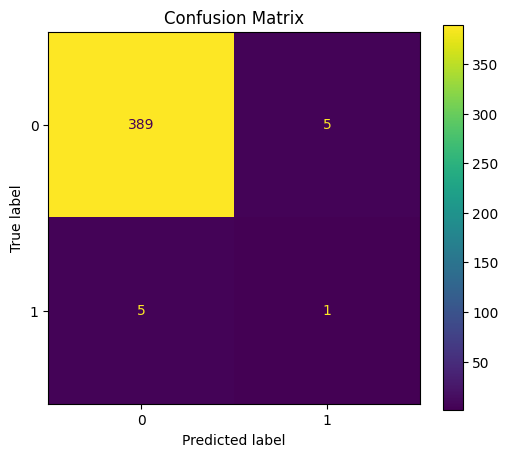

In [303]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import os

os.makedirs('results', exist_ok=True)

y_pred = model.predict(x_test)

y_pred = (y_pred > 0.5)

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

fig, ax = plt.subplots(figsize=(6,5))

ConfusionMatrixDisplay(confusion_matrix=cm).plot(ax=ax)

plt.title("Confusion Matrix")

plt.savefig(
    'results/evaluation_outputs.png',
    bbox_inches='tight'
)

plt.show()

Explanation : 
The confusion matrix showed that the neural network model correctly classified 389 retained customers and correctly identified 1 churn customer. However, 5 retained customers are incorrectly predicted as churn, and 5 churn customers are incorrectly classified as retained.



#### d. Brief interpretation of the result
The neural network model achieved high training and testing accuracy with relatively low loss values, indicating effective learning from the dataset. However, confusion matrix analysis showed that churn prediction remained difficult because the dataset is highly imbalanced. The classification report indicated very high precision, recall, and F1-score for the retained customer class because the dataset contained a large number of retained samples. In contrast, the churn class achieved lower precision, recall, and F1-score values due to the severe class imbalance in the dataset.

Although the overall accuracy remained high at approximately 97%, the confusion matrix and classification metrics revealed that predicting churn customers is still challenging. This demonstrates why confusion matrix, precision, recall, and F1-score are more informative than accuracy alone for imbalanced classification problems.

# Task 5: Hyperparameter Experimentation


#### Experiment with Different Number of Hidden Layers

##### Model with Two Hidden Layers

In [304]:
model_2layers = Sequential()

model_2layers.add(Dense(16, activation='relu', input_shape=(24,)))
model_2layers.add(Dense(8, activation='relu'))

model_2layers.add(Dense(1, activation='sigmoid'))

model_2layers.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history = model_2layers.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    class_weight={0:1, 1:15}
)

c:\Users\Home\Desktop\Business Analytics with Gen AI\Neural Networks & Deep Learning\Assignment Module 5\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9219 - loss: 0.7584 - val_accuracy: 0.9656 - val_loss: 0.2810
Epoch 2/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9695 - loss: 0.6748 - val_accuracy: 0.9875 - val_loss: 0.2534
Epoch 3/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9781 - loss: 0.6251 - val_accuracy: 0.9875 - val_loss: 0.2337
Epoch 4/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9781 - loss: 0.5844 - val_accuracy: 0.9875 - val_loss: 0.2185
Epoch 5/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9773 - loss: 0.5517 - val_accuracy: 0.9875 - val_loss: 0.2065
Epoch 6/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9781 - loss: 0.5231 - val_accuracy: 0.9875 - val_loss: 0.1951
Epoch 7/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9781 - loss: 0.4987 - val_accuracy: 0.9875 - val_loss: 0.1852
Epoch 8/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9789 - loss: 0.4765 - val_accuracy: 0.9875 - val_loss

In [305]:
from sklearn.metrics import confusion_matrix

y_pred = model_2layers.predict(x_test)

y_pred = (y_pred > 0.5)

cm = confusion_matrix(y_test, y_pred)

print(cm)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
[[387   7]
 [  5   1]]


##### Model with Three Hidden Layers

In [306]:
model_3layers = Sequential()

model_3layers.add(Dense(64, activation='relu', input_shape=(24,)))
model_3layers.add(Dense(32, activation='relu'))
model_3layers.add(Dense(16, activation='relu'))

model_3layers.add(Dense(1, activation='sigmoid'))
model_3layers.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history = model_3layers.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    class_weight={0:1, 1:15}
)

Epoch 1/10


c:\Users\Home\Desktop\Business Analytics with Gen AI\Neural Networks & Deep Learning\Assignment Module 5\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.9312 - loss: 0.7209 - val_accuracy: 0.9937 - val_loss: 0.2629
Epoch 2/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9820 - loss: 0.5717 - val_accuracy: 0.9937 - val_loss: 0.2101
Epoch 3/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9820 - loss: 0.5068 - val_accuracy: 0.9937 - val_loss: 0.1927
Epoch 4/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.9828 - loss: 0.4604 - val_accuracy: 0.9906 - val_loss: 0.1734
Epoch 5/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.9828 - loss: 0.4222 - val_accuracy: 0.9812 - val_loss: 0.1557
Epoch 6/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9844 - loss: 0.3886 - val_accuracy: 0.9812 - val_loss: 0.1445
Epoch 7/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9812 - loss: 0.3524 - val_accuracy: 0.9781 - val_loss: 0.1385
Epoch 8/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9789 - loss: 0.3212 - val_accuracy: 0.9781 - val_loss: 0.1303

In [307]:
from sklearn.metrics import confusion_matrix

y_pred = model_3layers.predict(x_test)
y_pred = (y_pred > 0.5)
cm = confusion_matrix(y_test, y_pred)

print(cm)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
[[380  14]
 [  5   1]]


#### Experiment with Changing Number of Neurons in Hidden Layer


##### Model With 32 Neurons

In [308]:
model_32 = Sequential()

model_32.add(Dense(32, activation='relu', input_shape=(24,)))
model_32.add(Dense(1, activation='sigmoid'))

model_32.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history = model_32.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    class_weight={0:1, 1:15}
)

Epoch 1/10


c:\Users\Home\Desktop\Business Analytics with Gen AI\Neural Networks & Deep Learning\Assignment Module 5\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7461 - loss: 0.7618 - val_accuracy: 0.9312 - val_loss: 0.4423
Epoch 2/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9391 - loss: 0.6200 - val_accuracy: 0.9812 - val_loss: 0.3300
Epoch 3/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9656 - loss: 0.5554 - val_accuracy: 0.9844 - val_loss: 0.2768
Epoch 4/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9680 - loss: 0.5178 - val_accuracy: 0.9875 - val_loss: 0.2487
Epoch 5/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9703 - loss: 0.4924 - val_accuracy: 0.9844 - val_loss: 0.2316
Epoch 6/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9672 - loss: 0.4727 - val_accuracy: 0.9812 - val_loss: 0.2204
Epoch 7/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9641 - loss: 0.4561 - val_accuracy: 0.9812 - val_loss: 0.2116
Epoch 8/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9617 - loss: 0.4414 - val_accuracy: 0.9812 - val_loss: 0.2044
Ep

In [309]:
from sklearn.metrics import confusion_matrix

y_pred = model_32.predict(x_test)
y_pred = (y_pred > 0.5)
cm = confusion_matrix(y_test, y_pred)

print(cm)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
[[380  14]
 [  3   3]]


##### Model With 64 Neurons

In [310]:
model_64 = Sequential()

model_64.add(Dense(64, activation='relu', input_shape=(24,)))
model_64.add(Dense(1, activation='sigmoid'))

model_64.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history = model_64.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    class_weight={0:1, 1:15}
)

Epoch 1/10


c:\Users\Home\Desktop\Business Analytics with Gen AI\Neural Networks & Deep Learning\Assignment Module 5\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.8258 - loss: 0.7882 - val_accuracy: 0.9719 - val_loss: 0.4011
Epoch 2/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9742 - loss: 0.6284 - val_accuracy: 0.9875 - val_loss: 0.3060
Epoch 3/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9781 - loss: 0.5600 - val_accuracy: 0.9812 - val_loss: 0.2643
Epoch 4/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9766 - loss: 0.5163 - val_accuracy: 0.9812 - val_loss: 0.2410
Epoch 5/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9688 - loss: 0.4844 - val_accuracy: 0.9781 - val_loss: 0.2247
Epoch 6/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9688 - loss: 0.4599 - val_accuracy: 0.9719 - val_loss: 0.2128
Epoch 7/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9695 - loss: 0.4396 - val_accuracy: 0.9719 - val_loss: 0.2029
Epoch 8/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.9648 - loss: 0.4222 - val_accuracy: 0.9656 - val_loss: 0.1948


In [311]:
from sklearn.metrics import confusion_matrix

y_pred = model_64.predict(x_test)
y_pred = (y_pred > 0.5)
cm = confusion_matrix(y_test, y_pred)

print(cm)

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step 
[[386   8]
 [  4   2]]


#### Experiment with Different Learning Rates

##### Model With Learning Rate = 0.01

In [312]:
from tensorflow.keras.optimizers import Adam

In [313]:

model_lr_01 = Sequential()

model_lr_01.add(Dense(16, activation='relu', input_shape=(24,)))
model_lr_01.add(Dense(1, activation='sigmoid'))

optimizer = Adam(learning_rate=0.01)

model_lr_01.compile(
    optimizer=optimizer,
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history = model_lr_01.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    class_weight={0:1, 1:15}
)

Epoch 1/10


c:\Users\Home\Desktop\Business Analytics with Gen AI\Neural Networks & Deep Learning\Assignment Module 5\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.9328 - loss: 0.7329 - val_accuracy: 0.9625 - val_loss: 0.2708
Epoch 2/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9641 - loss: 0.5027 - val_accuracy: 0.9344 - val_loss: 0.2373
Epoch 3/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9523 - loss: 0.4437 - val_accuracy: 0.9344 - val_loss: 0.2192
Epoch 4/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9516 - loss: 0.4049 - val_accuracy: 0.9438 - val_loss: 0.2036
Epoch 5/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9547 - loss: 0.3712 - val_accuracy: 0.9406 - val_loss: 0.1952
Epoch 6/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9508 - loss: 0.3438 - val_accuracy: 0.9406 - val_loss: 0.1792
Epoch 7/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9578 - loss: 0.3161 - val_accuracy: 0.9312 - val_loss: 0.1740
Epoch 8/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9570 - loss: 0.2895 - val_accuracy: 0.9312 - val_loss: 0.1597
Ep

In [314]:
from sklearn.metrics import confusion_matrix

y_pred = model_lr_01.predict(x_test)
y_pred = (y_pred > 0.5)
cm = confusion_matrix(y_test, y_pred)

print(cm)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
[[373  21]
 [  5   1]]


##### Model With Learning Rate = 0.0001

In [315]:

model_lr_0001 = Sequential()

model_lr_0001.add(Dense(16, activation='relu', input_shape=(24,)))
model_lr_0001.add(Dense(1, activation='sigmoid'))

optimizer = Adam(learning_rate=0.0001)

model_lr_0001.compile(
    optimizer=optimizer,
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history = model_lr_0001.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    class_weight={0:1, 1:15}
)

c:\Users\Home\Desktop\Business Analytics with Gen AI\Neural Networks & Deep Learning\Assignment Module 5\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.8531 - loss: 0.7351 - val_accuracy: 0.8438 - val_loss: 0.4430
Epoch 2/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8633 - loss: 0.7280 - val_accuracy: 0.8562 - val_loss: 0.4356
Epoch 3/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8758 - loss: 0.7220 - val_accuracy: 0.8656 - val_loss: 0.4286
Epoch 4/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8828 - loss: 0.7163 - val_accuracy: 0.8781 - val_loss: 0.4220
Epoch 5/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8891 - loss: 0.7109 - val_accuracy: 0.8844 - val_loss: 0.4158
Epoch 6/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8977 - loss: 0.7057 - val_accuracy: 0.8906 - val_loss: 0.4098
Epoch 7/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9023 - loss: 0.7007 - val_accuracy: 0.8969 - val_loss: 0.4040
Epoch 8/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9141 - loss: 0.6958 - val_accuracy: 0.8969 - val_loss

In [316]:
from sklearn.metrics import confusion_matrix

y_pred = model_lr_0001.predict(x_test)
y_pred = (y_pred > 0.5)
cm = confusion_matrix(y_test, y_pred)

print(cm)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
[[376  18]
 [  4   2]]


#### Comparison Table Showing How Each Configuration Affected Model Performance

In [317]:
from sklearn.metrics import confusion_matrix

models = {
    '1 Hidden Layer': model,
    '2 Hidden Layers': model_2layers,
    '3 Hidden Layers': model_3layers,
    '32 Neurons': model_32,
    '64 Neurons': model_64,
    'Learning Rate 0.01': model_lr_01,
    'Learning Rate 0.0001': model_lr_0001
}

accuracy_data = []

confusion_data = []

for name, mdl in models.items():

    loss, accuracy = mdl.evaluate(
        x_test,
        y_test,
        verbose=0
    )

    y_pred = mdl.predict(x_test)

    y_pred = (y_pred > 0.5)

    cm = confusion_matrix(y_test, y_pred)

    tn, fp, fn, tp = cm.ravel()

    accuracy_data.append({
        'Model': name,
        'Accuracy': round(accuracy, 4)
    })

    confusion_data.append({
        'Model': name,
        'True Negative (TN)': tn,
        'False Positive (FP)': fp,
        'False Negative (FN)': fn,
        'True Positive (TP)': tp
    })

accuracy_df = pd.DataFrame(accuracy_data)

confusion_df = pd.DataFrame(confusion_data)

print("Accuracy Comparison Table")
print(accuracy_df)

print("\nConfusion Matrix Comparison Table")
print(confusion_df)

accuracy_df.to_csv(
    'results/model_accuracy_comparison.csv',
    index=False
)

confusion_df.to_csv(
    'results/model_confusion_matrix_comparison.csv',
    index=False
)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
Accuracy Comparison Table
                  Model  Accuracy
0        1 Hidden Layer    0.9750
1       2 Hidden Layers    0.9700
2       3 Hidden Layers    0.9525
3            32 Neurons    0.9575
4            64 Neurons    0.9700
5    Learning Rate 0.01    0.9350
6  Learning Rate 0.0001    0.9450

Confusion Matrix Comparison Table
                  Model  True Negative (TN)  False Positive (FP)  \
0        1 Hidden Layer                 389                    5   
1       2 Hidden Layers                 387                    7   
2       3 Hidden Layers                 380                   14   
3            32 Neurons                 380                   14   
4            64 Neurons                 386    

Explanation : 
Multiple hyperparameter experiments are conducted by changing the number of hidden layers, number of neurons, and learning rate. The performance of each model is compared using training accuracy, validation accuracy, loss values, and confusion matrix results.

The experiments showed that increasing hidden layers and neurons slightly affected model performance, but all models continued to face difficulty in accurately predicting churn customers because of the severe class imbalance in the dataset.

Among the tested configurations, models with balanced learning rates and appropriate neuron sizes achieved better validation performance and slightly improved churn detection. The confusion matrix comparison also showed that some models produced fewer false negatives, which is important in churn prediction problems.

# Task 6: Final Reflection

#### Role of Weights and Biases

Weights and biases help the neural network learn relationships between input features and the target variable. During training, the model continuously updates these values to reduce prediction error and improve performance.

#### Importance of Activation Function

Activation functions introduce non-linearity into the neural network. Without activation functions, the model would behave like a simple linear model and would not be able to learn complex patterns from the dataset.

#### Effect of Learning Rate

The learning rate controls how quickly the model updates its weights during training. A very high learning rate may cause unstable learning, while a very low learning rate can make training slow and inefficient.

#### Underfitting and Overfitting Analysis

The model achieved high training and testing accuracy without large differences between training and validation performance, indicating that severe overfitting was not observed. However, the confusion matrix showed that churn prediction remained difficult because of the highly imbalanced dataset.